In [5]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import search_around, match_coord

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
dr9ref = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/tmp/gaia-mask-dr9.fits', columns=['mask_mag']))

mask = dr9ref['mask_mag']<8
idx = np.where(mask)[0]
dr9ref = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/tmp/gaia-mask-dr9.fits', rows=idx))
print(len(dr9ref))

25057


In [43]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_dr9_reference.fits', columns=['mask_mag']))

mask = cat['mask_mag']<10
idx = np.where(mask)[0]
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_dr9_reference.fits', rows=idx))

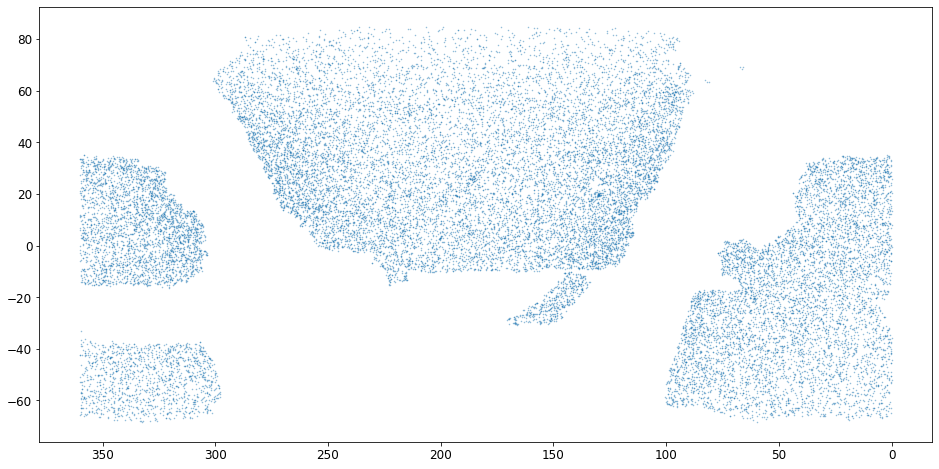

In [179]:
plt.figure(figsize=(16, 8))
plt.plot(dr9ref['ra'], dr9ref['dec'], '.', ms=1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

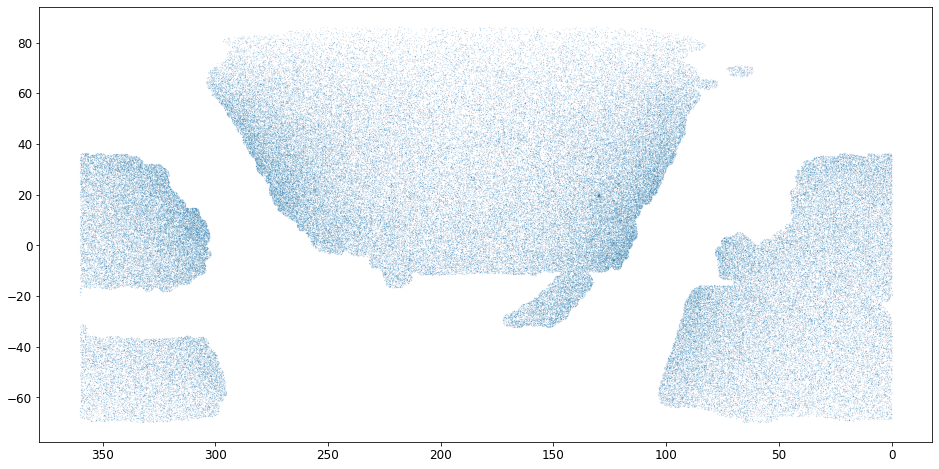

In [180]:
idx = np.random.choice(len(cat), size=len(cat), replace=False)
plt.figure(figsize=(16, 8))
plt.plot(cat['RA'][idx], cat['DEC'][idx], '.', ms=0.2, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

Doubly matched objects = 44
Final matched objects = 25013


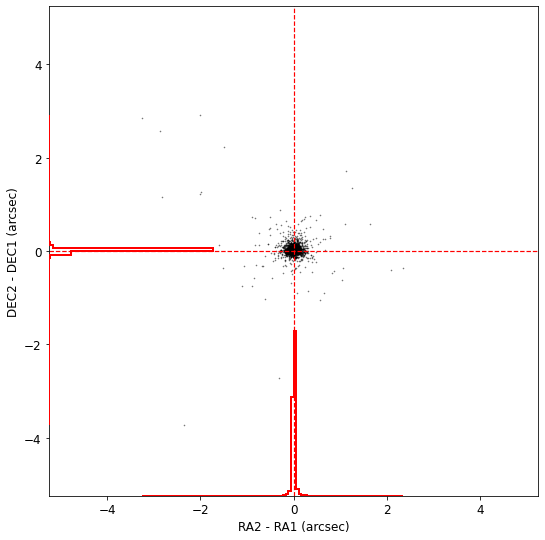

0.001755996328371312


In [6]:
idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], dr9ref['ra'], dr9ref['dec'], priority2=-dr9ref['mask_mag'], search_radius=5., plot_q=True)
print(1-len(idx2)/len(dr9ref))

In [9]:
idx1, idx2, d2d, d_ra, d_dec = search_around(cat['RA'], cat['DEC'], dr9ref['ra'], dr9ref['dec'], search_radius=5.)
print(len(dr9ref)-len(np.unique(idx2)))

27511 nearby objects
0


In [10]:
mask_missing = np.full(len(dr9ref), True)
mask_missing[idx2] = False
print(np.sum(mask_missing), np.sum(mask_missing)/len(dr9ref))

0 0.0


In [11]:
# Find the brightest mag from new catalog for each for the old catalog star
idx2_unique = np.unique(idx2)
mask_mag = np.zeros(len(idx2_unique))
for ii, index2 in enumerate(idx2_unique):
    mask = idx2==index2
    mask_mag[ii] = np.min(cat['mask_mag'][idx1[mask]])

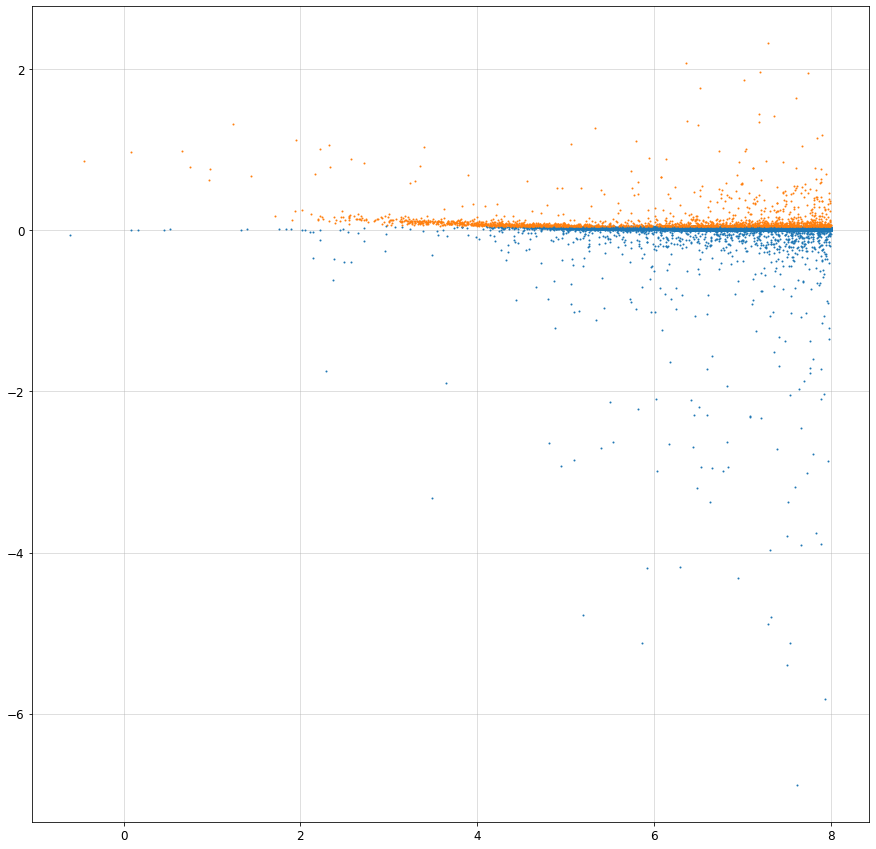

In [13]:
mask = mask_mag-dr9ref['mask_mag'][idx2_unique] > 0.05

plt.figure(figsize=(15, 15))
plt.plot(dr9ref['mask_mag'][idx2_unique][~mask],(mask_mag-dr9ref['mask_mag'][idx2_unique])[~mask], '.', ms=2)
plt.plot(dr9ref['mask_mag'][idx2_unique][mask], (mask_mag-dr9ref['mask_mag'][idx2_unique])[mask], '.', ms=2)
plt.grid(alpha=0.5)
plt.show()

In [28]:
dr9ref_add = dr9ref[idx2_unique[mask]].copy()

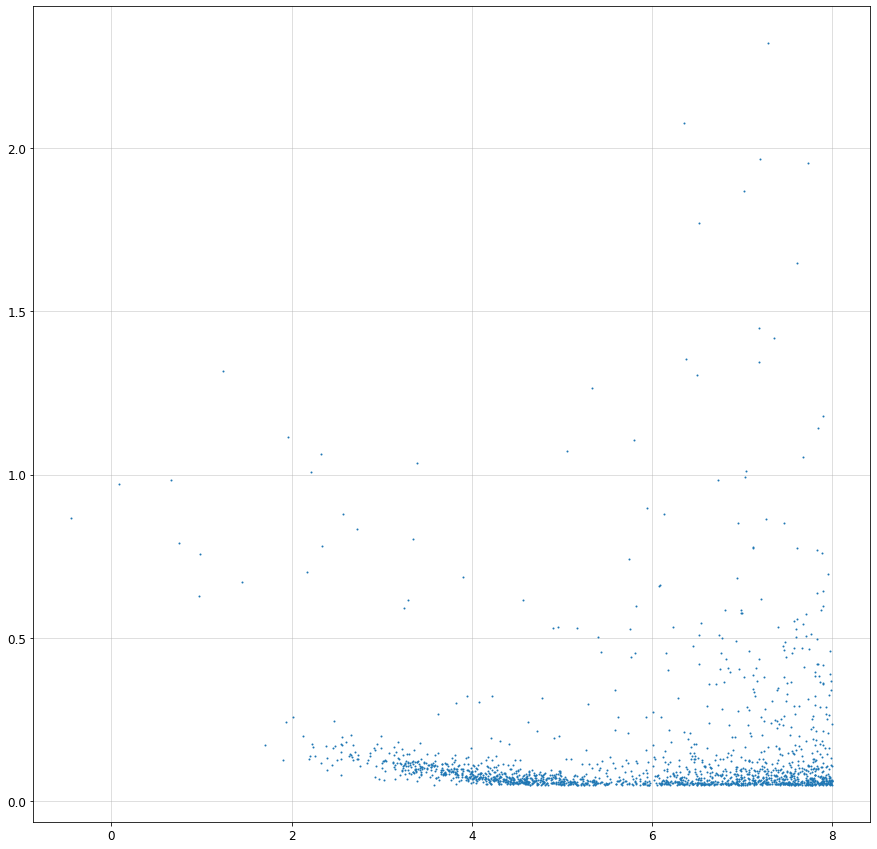

In [30]:
plt.figure(figsize=(15, 15))
plt.plot(dr9ref_add['mask_mag'], mask_mag[mask]-dr9ref_add['mask_mag'], '.', ms=2)
plt.grid(alpha=0.5)
plt.show()

In [35]:
dr9ref_add

ra,dec,ref_cat,ref_id,ref_epoch,mag,mask_mag,radius,radius_pix,pmra,pmdec,parallax,ra_ivar,dec_ivar,pmra_ivar,pmdec_ivar,parallax_ivar,in_desi,istycho,isgaia,isbright,ismedium,pointsource,donotfit,decam_mag_g,decam_mag_r,decam_mag_z,zguess,brickname,ibx,iby,gaia_phot_g_mean_mag,gaia_phot_g_mean_flux_over_error,gaia_phot_g_n_obs,gaia_phot_bp_mean_mag,gaia_phot_bp_mean_flux_over_error,gaia_phot_bp_n_obs,gaia_phot_rp_mean_mag,gaia_phot_rp_mean_flux_over_error,gaia_phot_rp_n_obs,gaia_phot_variable_flag,gaia_astrometric_excess_noise,gaia_astrometric_excess_noise_sig,gaia_astrometric_n_obs_al,gaia_astrometric_n_good_obs_al,gaia_astrometric_weight_al,gaia_duplicated_source,gaia_a_g_val,gaia_e_bp_min_rp_val,gaia_phot_bp_rp_excess_factor,gaia_astrometric_sigma5d_max,gaia_astrometric_params_solved
float64,float64,str2,int64,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,bool,bool,bool,bool,bool,bool,bool,float32,float32,float32,float32,str8,int32,int32,float32,float32,int16,float32,float32,int16,float32,float32,int16,bool,float32,float32,int16,int16,float32,bool,float32,float32,float32,float32,uint8
112.76849622067077,82.41128800051798,G2,1148730170578219136,2015.5,3.6955898,3.3438158,0.14839351,2039,-5.2489495,-42.174107,6.490762,322628950000000.0,330409720000000.0,5.2200627,6.042942,20.589453,False,True,True,True,True,True,False,5.3463163,3.905114,2.3438158,2.3438158,1134p825,3013,588,3.6955898,312.1267,361,5.171135,135.42543,40,2.7715356,170.6645,45,False,1.400219,976.62054,333,285,0.46887115,False,nan,nan,1.1861607,0.2206968,31
251.49326929760522,82.03726855860468,G2,1710727122295911040,2015.5,3.8942094,3.8942094,0.12350112,1697,19.919926,1.2872672,10.244639,267638390000000.0,219101050000000.0,4.519909,3.0187914,17.215763,False,True,True,True,True,True,False,4.426931,3.7659137,3.4918852,3.4918852,2514p820,1756,2312,3.8942094,217.78471,284,4.4521527,324.28162,29,3.3731217,462.46994,29,False,1.511907,1118.7317,268,237,0.40331453,False,nan,nan,1.1269879,0.30283856,31
116.72003323882564,81.68238094681743,G2,1148489716832712576,2015.5,7.804248,7.804248,0.033509143,461,-4.6630316,-13.942077,3.004753,1.3013706e+16,9443803000000000.0,259.7383,230.91606,557.2567,False,True,True,True,True,True,False,7.8295302,7.837104,8.008569,8.008569,1174p817,3208,879,7.804248,219.80907,245,7.921764,83.30702,28,7.629131,60.352745,28,False,0.09221718,2.9071774,210,205,41.89012,False,0.8445,0.413,1.1585389,0.04328764,31
144.2715659279724,81.32630955697383,G2,1144716265940854016,2015.5,3.7050915,3.7050915,0.1315441,1808,-16.794258,-17.604992,3.717828,216514640000000.0,189060230000000.0,2.681904,3.993344,12.04208,False,True,True,True,True,True,False,4.7514915,3.562414,2.925198,2.925198,1438p812,904,2851,3.7050915,212.16203,185,4.5957785,210.4662,24,2.9995944,153.14706,23,False,1.0359291,340.96716,135,128,0.84026474,True,0.51,0.199,1.1386698,0.32436797,31
180.07575258595082,80.85301819732983,G2,1718111511107661312,2015.5,5.220193,4.970834,0.08623503,1185,-64.82126,-38.699486,3.160132,2663377700000000.0,3567145600000000.0,50.47737,65.95908,213.97849,False,True,True,True,True,True,False,6.777957,5.3385196,3.9708338,3.9708338,1807p807,3300,3224,5.220193,440.00784,400,6.460902,94.45598,39,4.217477,140.18024,35,False,0.43855414,110.85731,357,327,4.6718373,False,1.1105,0.516,1.3066174,0.08352025,31
234.9100724403314,79.98338654459037,G2,1708946939955140352,2015.5,7.08009,7.08009,0.04266613,587,-32.642693,41.424778,8.108965,124360275000000.0,219492100000000.0,2.3470225,4.013775,12.367008,False,True,True,True,True,True,False,7.234767,7.0592675,7.0958257,7.0958257,2345p800,979,1574,7.08009,89.26881,275,7.0110736,235.85915,29,6.4944096,303.38397,25,False,1.5612829,353.05292,234,199,0.39997178,False,nan,nan,1.5119199,0.33441252,31
132.70661925795397,78.96141495064543,G2,1144004190427959552,2015.5,6.745963,5.810979,0.06515668,896,2.5663488,-20.555347,1.5577897,8101925000000000.0,4963618500000000.0,133.48174,118.70657,38